In [23]:
# 1. Install the required packages:
# $ conda install ipykernel ipywidgets
# $ conda install jupyterlab 

# 2. Register the preferred kernel
# $ conda activate env_name
# $ jupyter kernelspec list 
# $ python -m ipykernel install --user --name=env_name --display-name="Python (env_name)"

In [18]:
# Check local environment and executable | uncomment to debug
# import sys
# print(sys.executable)
# print(sys.path)

/Users/patricktoche/miniconda3/envs/jt/bin/python
['/Users/patricktoche/miniconda3/envs/jt/lib/python314.zip', '/Users/patricktoche/miniconda3/envs/jt/lib/python3.14', '/Users/patricktoche/miniconda3/envs/jt/lib/python3.14/lib-dynload', '', '/Users/patricktoche/miniconda3/envs/jt/lib/python3.14/site-packages', '/Users/patricktoche/miniconda3/envs/jt/lib/python3.14/site-packages']


In [21]:
# Load required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from tqdm.notebook import tqdm
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('data-parkinson.csv')

In [7]:
pd.set_option('display.max_columns', 10)
df.head(5)

,id,gender,PPE,DFA,RPDE,...,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,...,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,...,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,...,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,...,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,...,11.6891,8.2103,5.0559,6.1164,1


In [8]:
df.shape

(756, 755)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,756.0,125.500000,72.793721,0.000000,62.750000,125.500000,188.250000,251.00000
gender,756.0,0.515873,0.500079,0.000000,0.000000,1.000000,1.000000,1.00000
PPE,756.0,0.746284,0.169294,0.041551,0.762833,0.809655,0.834315,0.90766
DFA,756.0,0.700414,0.069718,0.543500,0.647053,0.700525,0.754985,0.85264
RPDE,756.0,0.489058,0.137442,0.154300,0.386537,0.484355,0.586515,0.87123
...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,756.0,12.375335,16.341665,1.628700,3.114375,4.741450,12.201325,73.53220
tqwt_kurtosisValue_dec_34,756.0,14.799230,15.722502,1.861700,3.665925,6.725700,21.922050,62.00730
tqwt_kurtosisValue_dec_35,756.0,14.751559,14.432979,1.955900,3.741275,7.334250,22.495175,57.54430
tqwt_kurtosisValue_dec_36,756.0,31.481110,34.230991,2.364000,3.948750,10.637250,61.125325,156.42370


In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
# Create an aggregation dictionary: features get the mean, class gets the first value
agg_dict = {col: 'mean' for col in df.columns if col not in ['id', 'class']}
agg_dict['class'] = 'first'  # Keeps the classification label intact

# Safely group by 'id' without corrupting or losing the 'class' column
df1 = df.groupby('id').agg(agg_dict).reset_index().drop(columns=['id'])

# Calculate the correlation matrix
corr_matrix = df1.drop(columns=['class']).corr()
corr_matrix

# Select the upper triangle of the correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
upper_tri

# Find features with a correlation greater than 0.7
to_drop = [column for column in upper_tri.columns if (upper_tri[column] > 0.7).any()]

# Drop the highly correlated columns from your original DataFrame
df1 = df1.drop(columns=to_drop)

df1.shape

(252, 220)

In [13]:
# Separate features (X) and target (y)
X = df1.drop('class', axis=1)
y = df1['class']

# Scale the features to prevent negative values (required for Chi-Square)
X_norm = MinMaxScaler().fit_transform(X)

# Apply SelectKBest with Chi-Square to pick the top 30 features
selector = SelectKBest(chi2, k=30)
selector.fit(X_norm, y)

# Filter the columns based on the selector's support mask
filtered_columns = selector.get_support()
filtered_data = X.loc[:, filtered_columns]

# Append the 'class' column back to the final DataFrame
filtered_data['class'] = y
df2 = filtered_data

print(df2.shape)

(252, 31)


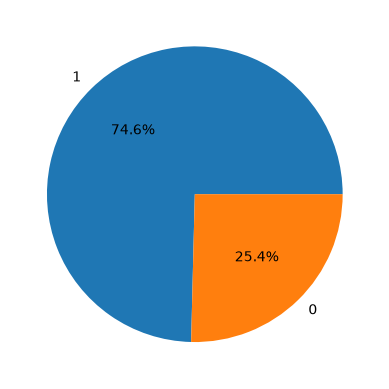

In [14]:
vc = df2['class'].value_counts()
plt.pie(vc.values,
		labels = vc.index,
		autopct='%1.1f%%')
plt.show()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=10)

ros = RandomOverSampler(sampling_strategy=1.0, random_state=0)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

X_resampled.shape, y_resampled.value_counts()

((302, 219),
 class
 1    151
 0    151
 Name: count, dtype: int64)

In [16]:
from sklearn.metrics import roc_auc_score

# Standard models list
models = [
    LogisticRegression(class_weight='balanced'), 
    XGBClassifier(), 
    SVC(kernel='rbf', probability=True)
]

# Model training and evaluation loop
for model in models:
    model.fit(X_resampled, y_resampled)
    
    # Clean naming format for the model printout
    print(f"{model.__class__.__name__} :")
    
    # Evaluate on the training set
    train_preds = model.predict(X_resampled)
    train_auc = roc_auc_score(y_resampled, train_preds)
    print(f"Training ROC AUC: {train_auc:.4f}")
    
    # Evaluate on the validation set
    val_preds = model.predict(X_test)
    val_auc = roc_auc_score(y_test, val_preds)
    print(f"Validation ROC AUC: {val_auc:.4f}")
    print()


LogisticRegression :
Training ROC AUC: 0.7053
Validation ROC AUC: 0.5434

XGBClassifier :
Training ROC AUC: 1.0000
Validation ROC AUC: 0.6737

SVC :
Training ROC AUC: 0.5993
Validation ROC AUC: 0.6371



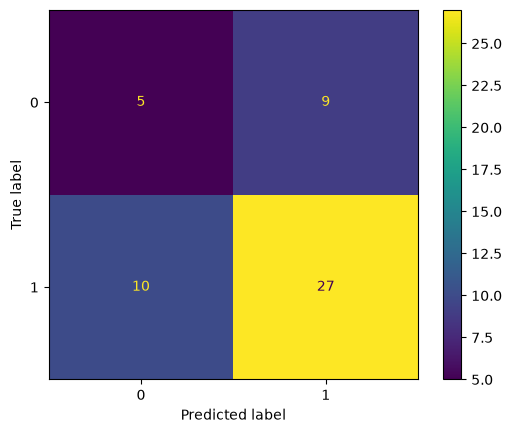

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(models[0], X_test, y_test)
plt.show()